# Applications

A throttle lane, a cruise through a gust, two joints on one wire, a hold against a load step.

## 1 Setup

In [1]:
SIMULATED = True          # False, and PORT, at the bench
PORT = 'COM4'

In [2]:
from coaxial import Coaxial63100

device = Coaxial63100(port=PORT, simulated=SIMULATED).open()
print(device)

<Coaxial63100 Simulated SIMULATED>


## 2 The stage, armed

The drive on the stand-in's rotor (`configure(source='model')`), the smallest plausible J and b, the stage armed once. The two flags are for a bench without STO or interlock.

In [3]:
drive = device.drive
drive.configure(source='model')
print(drive.model.configure(j=2e-5, b=1e-5, load=0.0))
device.gates.on(bypass_sto=True, ignore_interlock=True)
print('armed:', device.gates.is_on())

{'j': 2e-05, 'b': 1e-05, 'load': 0.0}
armed: True


## 3 The propeller on the rotor

`Propeller(k)`: `T = k w^2`; `on_model` feeds it to the model's load every pass. A pass: one state read, one setpoint write, 40 ms apart.

In [4]:
from coaxial.model.motor import APC20x10E, Propeller
from coaxial.model.sensorless import RAD_S_PER_RPM

K_PROP = 2e-8
prop = Propeller(K_PROP, name='stand-in propeller')
tune = drive.params()
poles = int(tune['motor_pole_pairs'])
kt = 1.5 * poles * tune['motor_lambda_uvs']
top = 3500.0 * RAD_S_PER_RPM
print(prop, ' ', APC20x10E)
print('kt %.4f N.m/A from the record, %d pole pairs' % (kt, poles))
for law in (prop, APC20x10E):
    torque = law.torque(top * poles, poles)
    print('%-20s at 3500 rpm: %.4f N.m, %5.2f A of iq' % (law.name, torque, torque / kt))

<stand-in propeller: 2.000e-08 N.m/(rad/s)^2>   <APC20x10E: 5.143e-06 N.m/(rad/s)^2>
kt 0.0525 N.m/A from the record, 7 pole pairs
stand-in propeller   at 3500 rpm: 0.0027 N.m,  0.05 A of iq
APC20x10E            at 3500 rpm: 0.6909 N.m, 13.16 A of iq


## 4 A throttle lane

One quadrotor lane: `velocity` with a 2 A clamp, a 3 Hz loop, `load_k` the propeller; four speeds, two seconds each. The reference slews over a third of the block.

In [5]:
import time

LANE = ((1500.0, 2.0), (3000.0, 2.0), (2000.0, 1.5), (3500.0, 2.0))
lane_log, lane_settled = [], []
with device.motion.velocity(amps=2.0, hz=3.0, load_k=K_PROP) as lane:
    air = prop.on_model(drive, lane_log)
    began = time.monotonic()
    for rpm, hold in LANE:
        got = lane.rpm(rpm, seconds=hold, watch=air)
        lane_settled.append((rpm, got))
        print('asked %5.0f  settled %5.0f rpm  (%+5.1f %%)' % (rpm, got, 100.0 * (got - rpm) / rpm))
    lane_wall = time.monotonic() - began
    lane.stop(seconds=1.0)
    lane_pause = lane.loop.pause
drive.model.configure(load=0.0)
print('%d passes in %.1f s: %.1f a second, %.0f ms a pass against %.0f ms asked'
      % (len(lane_log), lane_wall, len(lane_log) / lane_wall,
         1000.0 * lane_wall / len(lane_log), 1000.0 * lane_pause))

asked  1500  settled  1493 rpm  ( -0.4 %)


asked  3000  settled  2932 rpm  ( -2.3 %)


asked  2000  settled  2060 rpm  ( +3.0 %)


asked  3500  settled  3324 rpm  ( -5.0 %)


187 passes in 7.6 s: 24.6 a second, 41 ms a pass against 40 ms asked


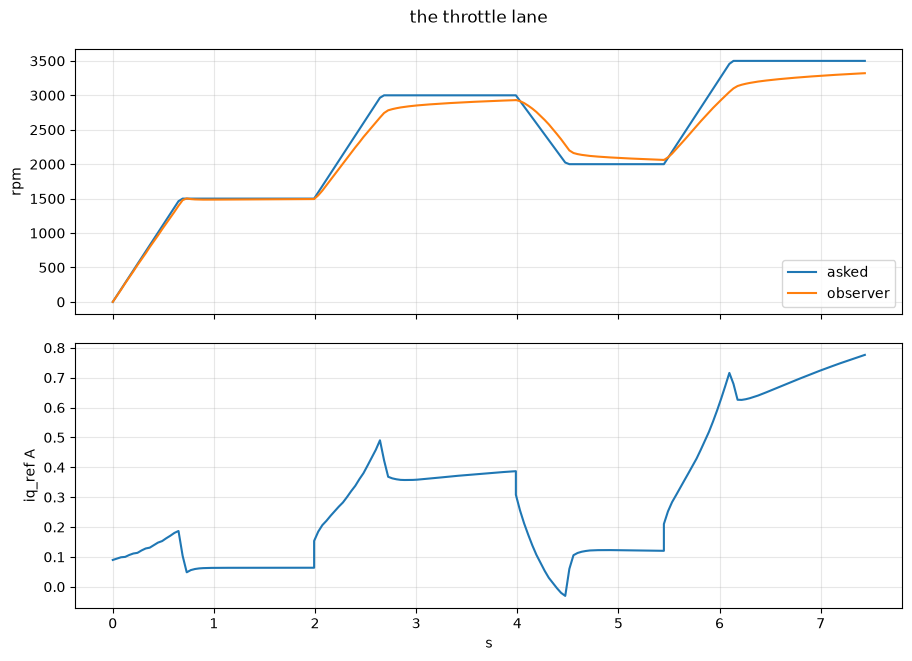

In [6]:
from coaxial.draw.figures import figure, show

def draw(log, title):
    t = [r[0] for r in log]
    fig, (speed, current) = figure(rows=2, sharex=True, title=title)
    speed.plot(t, [r[1] for r in log], label='asked')
    speed.plot(t, [r[2] for r in log], label='observer')
    speed.set_ylabel('rpm')
    speed.legend(loc='lower right')
    current.plot(t, [r[3] for r in log])
    current.set_ylabel('iq_ref A')
    current.set_xlabel('s')
    show(fig)

draw(lane_log, 'the throttle lane')

## 5 A cruise through a gust

2500 rpm held 5 s; drag x2.5 from 3.5 to 4.5 s, `load_k` not told.

cruise      2465 rpm, spread  53, iq_ref 0.21 A over 50 passes
gust        2402 rpm, spread 105, iq_ref 0.27 A over 24 passes
recovered   2526 rpm, spread  17, iq_ref 0.22 A over 23 passes
after the gust: 2518 rpm


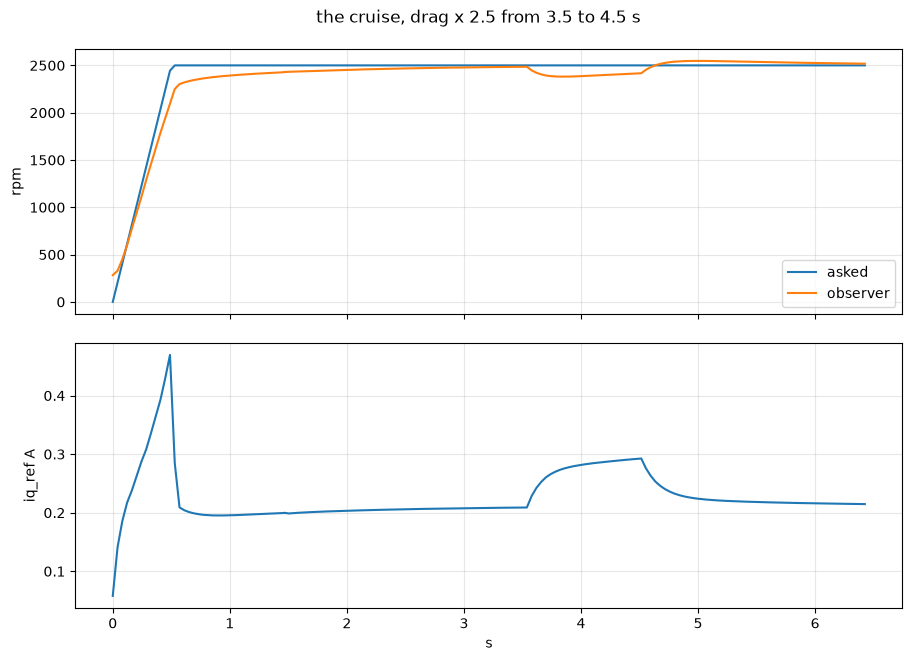

In [7]:
K_CRUISE = 2e-8
GUST, GUST_FROM, GUST_TO = 2.5, 3.5, 4.5        # times the drag, over which seconds
cruise_log = []
still_air = Propeller(K_CRUISE).on_model(drive, cruise_log)

def gusty(verb):
    still_air(verb)                             # the row, and the still-air load
    if GUST_FROM <= cruise_log[-1][0] < GUST_TO:
        wm = drive.model.read()['omega'] / verb.poles
        drive.model.configure(load=GUST * K_CRUISE * wm * abs(wm))

with device.motion.velocity(amps=2.0, hz=2.0, load_k=K_CRUISE) as cruise:
    cruise.rpm(2500.0, seconds=1.5, watch=gusty)
    cruise.rpm(2500.0, seconds=5.0, watch=gusty)
    after_gust = cruise.rpm_now
    cruise.stop(seconds=1.0)
drive.model.configure(load=0.0)

def window(log, lo, hi):
    rows = [r for r in log if lo <= r[0] < hi]
    speed = [r[2] for r in rows]
    return (sum(speed) / len(speed), max(speed) - min(speed),
            sum(r[3] for r in rows) / len(rows), len(rows))

WINDOWS = (('cruise', 1.5, GUST_FROM), ('gust', GUST_FROM, GUST_TO), ('recovered', 5.5, 6.5))
cruise_windows = {name: window(cruise_log, lo, hi) for name, lo, hi in WINDOWS}
for name, (mean, spread, amps, passes) in cruise_windows.items():
    print('%-10s %5.0f rpm, spread %3.0f, iq_ref %.2f A over %d passes' % (name, mean, spread, amps, passes))
print('after the gust: %.0f rpm' % after_gust)
draw(cruise_log, 'the cruise, drag x %.1f from %.1f to %.1f s' % (GUST, GUST_FROM, GUST_TO))

## 6 Two joints on one wire

One board a joint on one segment: `shoulder` unit 1, `elbow` unit 2. The elbow carries 0.01 N.m.

In [8]:
shoulder = device
elbow = Coaxial63100(port=PORT, unit=2, simulated=SIMULATED).open()
elbow.drive.configure(source='model')
elbow.drive.model.configure(j=2e-5, b=1e-5, load=0.01)
elbow.gates.on(bypass_sto=True, ignore_interlock=True)
for name, joint in (('shoulder', shoulder), ('elbow', elbow)):
    print('%-9s unit %d  %s  armed %s' % (name, joint.origin.unit, joint, joint.gates.is_on()))

shoulder  unit 1  <Coaxial63100 Simulated SIMULATED>  armed True
elbow     unit 2  <Coaxial63100 Simulated SIMULATED>  armed True


Per pose: slew at 90 deg/s, let the ring die, read the mean, correct - at most four times, inside 0.5 deg.

In [9]:
POSES = ((30.0, 60.0), (60.0, 20.0), (0.0, 0.0))
reached = []
with shoulder.motion.servo(amps=2.0) as s, elbow.motion.servo(amps=2.0) as e:
    for a, b in POSES:
        got_a = s.to(a, tol=0.5)
        got_b = e.to(b, tol=0.5)
        reached.append((a, b, got_a, s.error, s.swing, got_b, e.error, e.swing))
        print('pose (%5.1f, %5.1f)  shoulder %6.2f err %5.2f swing %4.2f   elbow %6.2f err %5.2f swing %4.2f'
              % reached[-1])
elbow.gates.off()
elbow.drive.model.configure(load=0.0)
elbow.drive.configure(source='adc')
elbow.close()
print(elbow)

pose ( 30.0,  60.0)  shoulder  30.01 err -0.01 swing 2.90   elbow  59.99 err  0.01 swing 4.39


pose ( 60.0,  20.0)  shoulder  60.00 err  0.00 swing 1.23   elbow  20.02 err -0.02 swing 2.72


pose (  0.0,   0.0)  shoulder   0.00 err -0.00 swing 0.79   elbow   0.09 err -0.09 swing 0.09
<Coaxial63100 Simulated SIMULATED>


## 7 A hold against a load step

30 deg at 3 A; 0.03 N.m steps on. Read every 2 ms relative to the hold (20 ms aliased the ~30 Hz ring, 2026-09-07).

In [10]:
def watch_shaft(seconds, about, every=0.002):
    rows = []
    t0 = time.monotonic()
    while time.monotonic() - t0 < seconds:
        now = device.angle.state()['degrees']
        rows.append((time.monotonic() - t0, (now - about + 180.0) % 360.0 - 180.0))
        time.sleep(every)
    return rows

with device.motion.servo(amps=3.0, settle=0.3) as hold:
    zero = hold.to(30.0, tol=0.25)
    print('held at %.2f deg, error %.2f, swing %.2f' % (zero, hold.error, hold.swing))
    origin = device.angle.state()['degrees']
    before = watch_shaft(0.5, origin)
    drive.model.configure(load=0.03)
    during = watch_shaft(0.8, origin)
    corrected = hold.to(30.0, tol=0.25)
    print('after the load step: shaft %.2f deg, error %.2f, swing %.2f'
          % (corrected, hold.error, hold.swing))
    after = watch_shaft(0.5, origin)
    drive.model.configure(load=0.0)
print('the sensor read %.2f deg at the hold; the trace counts from there' % origin)
device.gates.off()
drive.configure(source='adc')
print('armed:', device.gates.is_on(), ' drive:', drive.state()['mode'])

held at 30.00 deg, error 0.00, swing 0.26


after the load step: shaft 30.03 deg, error -0.03, swing 1.23


the sensor read 348.66 deg at the hold; the trace counts from there
armed: False  drive: off


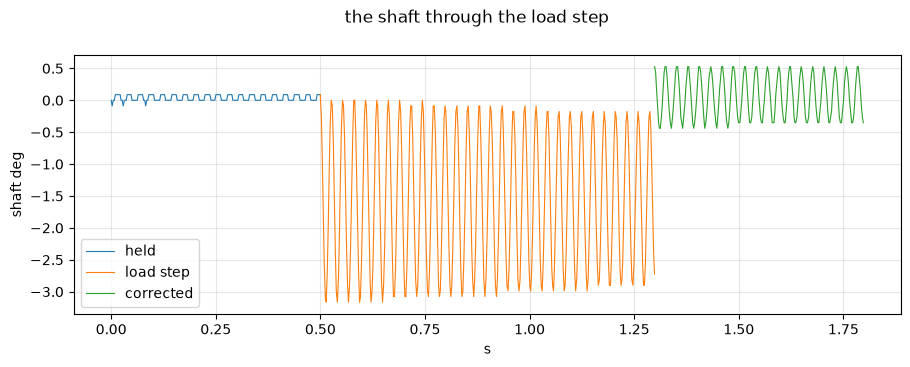

In [11]:
fig, (shaft,) = figure(rows=1, title='the shaft through the load step')
t = 0.0
for rows, label in ((before, 'held'), (during, 'load step'), (after, 'corrected')):
    shaft.plot([t + r[0] for r in rows], [r[1] for r in rows], linewidth=0.8, label=label)
    t += rows[-1][0]
shaft.set_xlabel('s')
shaft.set_ylabel('shaft deg')
shaft.legend(loc='lower left')
show(fig)

In [12]:
device.close()
print(device)

<Coaxial63100 Simulated SIMULATED>


## 8 Results

In [13]:
def held_at(log, target):
    rows = [r[2] for r in log if abs(r[1] - target) < 1.0]
    rows = rows[len(rows) // 2:]
    return sum(rows) / len(rows), max(rows) - min(rows), len(rows)

print('1. lane        %d passes in %.1f s: %.1f a second, %.0f ms a pass against %.0f ms asked'
      % (len(lane_log), lane_wall, len(lane_log) / lane_wall,
         1000.0 * lane_wall / len(lane_log), 1000.0 * lane_pause))
print('   iq_ref      %.2f A peak, %.2f A mean, clamp 2.0 A'
      % (max(abs(r[3]) for r in lane_log), sum(r[3] for r in lane_log) / len(lane_log)))
for asked, settled in lane_settled:
    mean, spread, passes = held_at(lane_log, asked)
    print('   at %4.0f rpm  settled %4.0f (%+5.1f %%), held %4.0f, spread %3.0f rpm over %d passes'
          % (asked, settled, 100.0 * (settled - asked) / asked, mean, spread, passes))
print('2. cruise      reference %.0f rpm from %.1f to %.1f s, gust x %.1f from %.1f to %.1f s'
      % (max(r[1] for r in cruise_log), 1.5, cruise_log[-1][0], GUST, GUST_FROM, GUST_TO))
for name, (mean, spread, amps, passes) in cruise_windows.items():
    print('   %-11s %5.0f rpm, spread %3.0f, iq_ref %.2f A over %d passes' % (name, mean, spread, amps, passes))
print('   after       %.0f rpm; the gust cost %.2f A more than cruise, %.2f A of it given back'
      % (after_gust, cruise_windows['gust'][2] - cruise_windows['cruise'][2],
         cruise_windows['gust'][2] - cruise_windows['recovered'][2]))
print('3. arm         worst shoulder error %.2f deg, worst elbow error %.2f deg under 0.01 N.m'
      % (max(abs(r[3]) for r in reached), max(abs(r[6]) for r in reached)))
print('   swing       up to %.2f deg shoulder, %.2f deg elbow while measured; tolerance 0.50 deg, up to 4 corrections a move'
      % (max(r[4] for r in reached), max(r[7] for r in reached)))
held = sum(r[1] for r in before) / len(before)
pulled = sum(r[1] for r in during[len(during) // 2:]) / (len(during) - len(during) // 2)
back = sum(r[1] for r in after) / len(after)
print('4. hold        from the hold: %+.2f before the load, %+.2f under 0.03 N.m (sag %.2f), %+.2f corrected'
      % (held, pulled, pulled - held, back))
print('   ring        %.2f deg peak to peak held, %.2f under the load, %.2f corrected; sampled at %.0f Hz; 3.0 A, tol 0.25 deg'
      % tuple([max(r[1] for r in rows) - min(r[1] for r in rows) for rows in (before, during, after)]
              + [len(before) / before[-1][0]]))

1. lane        187 passes in 7.6 s: 24.6 a second, 41 ms a pass against 40 ms asked
   iq_ref      0.78 A peak, 0.30 A mean, clamp 2.0 A
   at 1500 rpm  settled 1493 ( -0.4 %), held 1491, spread   4 rpm over 17 passes
   at 3000 rpm  settled 2932 ( -2.3 %), held 2913, spread  41 rpm over 17 passes
   at 2000 rpm  settled 2060 ( +3.0 %), held 2074, spread  31 rpm over 13 passes
   at 3500 rpm  settled 3324 ( -5.0 %), held 3293, spread  61 rpm over 17 passes
2. cruise      reference 2500 rpm from 1.5 to 6.4 s, gust x 2.5 from 3.5 to 4.5 s
   cruise       2465 rpm, spread  53, iq_ref 0.21 A over 50 passes
   gust         2402 rpm, spread 105, iq_ref 0.27 A over 24 passes
   recovered    2526 rpm, spread  17, iq_ref 0.22 A over 23 passes
   after       2518 rpm; the gust cost 0.07 A more than cruise, 0.06 A of it given back
3. arm         worst shoulder error 0.01 deg, worst elbow error 0.09 deg under 0.01 N.m
   swing       up to 2.90 deg shoulder, 4.39 deg elbow while measured; tolerance

- 25 passes/s is the 40 ms pause; each speed settles within 5 % in its 2 s.
- The gust pulls 2500 rpm down about 100 for 0.07 A more; the loop gives both back.
- Both joints within 0.1 deg on every pose.
- The hold sags 1.6 deg under 0.03 N.m, as the spring says; one correction takes it back inside the 0.25 deg tolerance. Stiffness is current, not gain.

**Bench.** No flags on `gates.on()`, no `on_model`, `load_k` = `APC20x10E.k`, the record commissioned first. `for_others` climbs with the other joint's traffic.

## References

* `host/coaxial/control/motion.py` - the three verbs: the slew, the servo's mean over the ring, the velocity loop at link rate
* `host/coaxial/control/loop.py` - `SpeedLoop`: kp from the mechanical pole, the feedforward, the integrator held on the clamp and `v_sat`
* `host/coaxial/model/motor.py` - `Propeller`, `on_model`, `APC20x10E` off the thrust stand, and `Motor` with `k_load` beside `b`
* `host/coaxial/simulated/drive/` - the stand-in's rotor the missions turned, a pendulum integrated at a fixed sub-step
* `host/coaxial/devices/link.py` - `state(port)`: `bus_message`, `server_message`, and `for_others` between them
* `docs/FINDINGS.md` - the motion verbs, 2026-09-07: the aliased measurement, the pumped corrections, the rotor's step
* `host/tests/test_sensorless.py` - `test_motion`: the verbs against the stand-in, the dangerous paths included